In [1]:
#remeber we must scale the data while doing the PCA


In [2]:
#PCA EXAMPLE

In [4]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [5]:
df=pd.read_csv('diabetes.csv')
df

In [12]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [13]:
#Select only the numerical columns 
numerical_cols=['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']

In [14]:
#Handling the missing values
imputer=SimpleImputer(strategy='mean')
data_imputed=imputer.fit_transform(df[numerical_cols])

In [15]:
#Convert back to a dataFrame
data_clean=pd.DataFrame(data_imputed,columns=numerical_cols)

In [16]:
#Standardize (important for PCA)
#PCA is affected by feature scale -- we scale all the features to have mean=0 and std=1
scaler=StandardScaler()
data_scaled=scaler.fit_transform(data_clean)

In [17]:
#Apply PCA
#lets keep upto 7 components(can be fewer than the number of the columns)
pca=PCA(n_components=1)
data_pca=pca.fit_transform(data_scaled)

In [21]:
#6.Check how much information each component keeps 
explained_variance= pca.explained_variance_ratio_ #% of total info(variance) captured by each componenet
cumulative_variance = np.cumsum(explained_variance) #cumulativ total

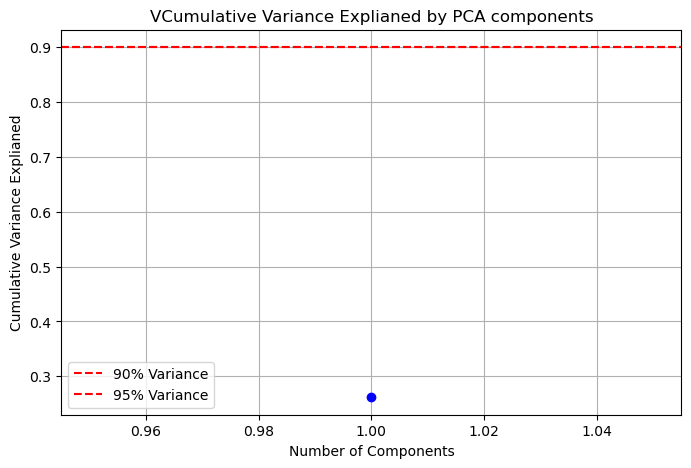

In [23]:
#7.Plot cumulative Variance 
plt.figure(figsize=(8,5))
plt.plot(range(1,len(cumulative_variance) + 1),cumulative_variance,marker='o',linestyle='--',color='b')
plt.title('VCumulative Variance Explianed by PCA components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explianed')
plt.axhline(y=0.9,color='r',linestyle='--',label='90% Variance')
plt.axhline(y=0.9,color='r',linestyle='--',label='95% Variance')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
#8.Print variance info 
print("Explained Varaince ratio (each PC shows how much info it captures):")
print(explained_variance.round(3))

Explained Varaince ratio (each PC shows how much info it captures):
[0.262]


In [25]:
print("\nCumulative Variance (how much total info is captured):")
print(cumulative_variance.round(3))


Cumulative Variance (how much total info is captured):
[0.262]


In [28]:
#9. Find feature contribution (loadngs)
#Loadings tell us how each original feature contibutes to each principal componrnt 
loadings=pd.DataFrame(pca.components_.T,#transpose to get features as rows
                      columns=[f'PC{i+1}' for i in range(pca.n_components_)],
                      index=numerical_cols
                      )

In [29]:
print("\nFeature Loadings (importanc eof each feature in each component):")
print(loadings.round(3))


Feature Loadings (importanc eof each feature in each component):
                            PC1
Pregnancies               0.128
Glucose                   0.393
BloodPressure             0.360
SkinThickness             0.440
Insulin                   0.435
BMI                       0.452
DiabetesPedigreeFunction  0.271
Age                       0.198


In [30]:
#Add on: logistic Regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [32]:
#10. Select optimal Number OF components (e.g for 955 varainace)
#Find the index of the first component where cumulative variance is >=0.95
index_of_95=np.argmax(cumulative_variance>=0.95)

In [34]:
#np.argmax returns the index of the first 'True'. If no True is found ,it returns 0.
#We must check if the 95% target was actually reached at the index.
if cumulative_variance[index_of_95]>=0.95:
    n_opt = index_of_95 +1
else:
    #If the target eas NOT reached, use all available components 
    n_opt = len(explained_variance)

In [37]:
print(f"\nOptimal number of components to retain 95% varaiance:{n_opt}")

#Use the optimally reduced data for modellinf
x_pca_reduced = data_pca[:,:n_opt]


Optimal number of components to retain 95% varaiance:1


In [36]:
#11.Prepare Data and Model 
y=df['Outcome']

In [40]:
#Split the data into training and testing sets 
X_train, X_test, y_train,y_test=train_test_split(
    x_pca_reduced,y,test_size=0.3,random_state=42,stratify=y)

In [41]:
#Initialize and train the Logistic Regression model
log_reg =LogisticRegression(solver='liblinear',random_state=42,max_iter=1000)
log_reg.fit(X_train,y_train)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

In [43]:
#a2.Predict and Evaluate
y_pred=log_reg.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
print(f"Model Accuracy:{accuracy:.4f}")

Model Accuracy:0.7316
